# Customer Churn Prediction 

In [588]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

from catboost import CatBoostClassifier
from sklearn import metrics
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report

In [589]:
## Load the Data 
df = pd.read_csv("../WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [590]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Understanding the data

In [591]:
df.shape

(7043, 21)

In [592]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [593]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [594]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [595]:
# checking for null values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [596]:
df.duplicated().sum()

np.int64(0)

### Data Manipulation 

In [597]:
## This column doesn't give us the required information we needed so we dropped it
df = df.drop(['customerID'], axis = 1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [598]:
# on deep analysis we can find some missing values in data which could be in the form blankspaces
# the TotalCharges column has numeric values, but it has dtype of str, so we will fix this
df['TotalCharges'] =  pd.to_numeric(df.TotalCharges, errors= 'coerce')
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

.As you can see 11 missing values have been discoverd in the dataset

In [599]:
df['TotalCharges'].dtype  ## the dtype is also converted into the float

dtype('float64')

In [600]:
# Identify missing TotalCharges data, filling it with NaN
df[np.isnan(df['TotalCharges'])]


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [601]:
df[df['tenure']== 0].index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

In [602]:
## lets drop the above values
df.drop(labels=df[df['tenure']== 0].index, axis=0, inplace=True)
df[df['tenure']== 0].index

Index([], dtype='int64')

In [603]:
## fill the missing values in the TotalCharges with mean
df.fillna(df['TotalCharges'].mean())
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [604]:
df['SeniorCitizen']= df['SeniorCitizen'].map({0:"No", 1: "Yes"})
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [605]:
# lets describe the internetservice coloum
df['InternetService'].describe(include=['object', 'bool'])

count            7032
unique              3
top       Fiber optic
freq             3096
Name: InternetService, dtype: object

In [606]:
df.dtypes

gender                  str
SeniorCitizen           str
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [607]:
# seperate the numerical columns 
numerical_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


## Data Visualization 

In [608]:
print(df['gender'].value_counts())
print(df['Churn'].value_counts())

gender
Male      3549
Female    3483
Name: count, dtype: int64
Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [609]:
g_labels = ['Male', 'Female']
c_labels = ['No', 'Yes']
 # create subplots, use "domain" type for Pie subplots
fig = make_subplots(rows=1, cols=2, specs= [[{'type': 'domain'}, {'type': 'domain'}]])
fig.add_trace(go.Pie(labels=g_labels, values=df['gender'].value_counts(), name= "Gender"), 1, 1)
fig.add_trace(go.Pie(labels=c_labels, values=df['Churn'].value_counts(), name= "Churn"), 1, 2)

  # Use "hole" to create like pie chart
fig.update_traces(hole=.4, hoverinfo = "label+percent+name", textfont_size = 16)

fig.update_layout(
    title_text = "Gender and Churn Distribution",
    # add anotations in the center of donut pie
    annotations = [dict(text = "Gender", x=0.16, y=0.5, font_size = 20, showarrow = False),
                   dict(text = "Churn", x=0.84, y=0.5, font_size = 20, showarrow = False)])
fig.show()

In [610]:
df['Churn'][df['Churn'] =='No'].groupby(by= df["gender"]).count()


gender
Female    2544
Male      2619
Name: Churn, dtype: int64

In [611]:
df['Churn'][df['Churn'] =='Yes'].groupby(by= df["gender"]).count()

gender
Female    939
Male      930
Name: Churn, dtype: int64

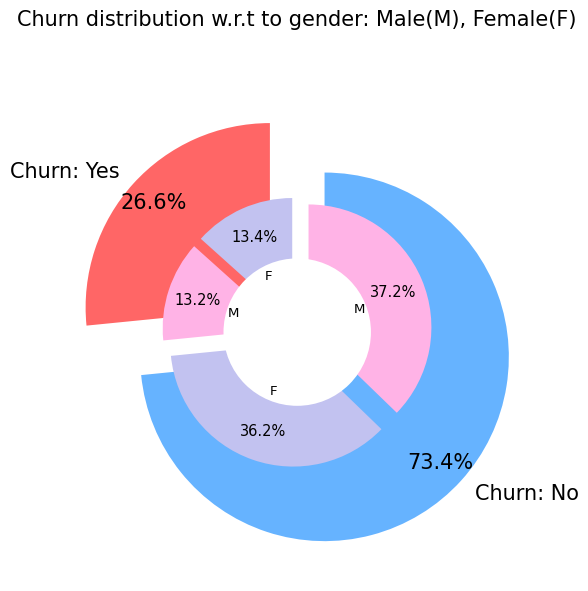

In [612]:
plt.figure(figsize=(6,6))
labels = ["Churn: Yes", "Churn: No"]
values = [1869, 5163]
labels_gender = ["F", "M", "F", "M"]
sizes_gender = [939, 930,  2544,2619]
colors = ['#ff6666','#66B3FF']
colors_gender = ['#c2c2f0', '#ffb3e6', '#c2c2f0', '#ffb3e6']
explode = (0.3, 0.3)
explode_gender = (0.1, 0.1, 0.1, 0.1)
textprops ={"fontsize": 15}
#plot
plt.pie(values, labels=labels, colors=colors, startangle=90, 
        radius=1.5, explode=explode, autopct='%1.1f%%', 
        pctdistance=0.85, textprops=textprops)

# Inner ring: Gender Breakdown
plt.pie(sizes_gender, labels=labels_gender, colors=colors_gender, 
        startangle=90, radius=1, explode=explode_gender, 
        autopct='%1.1f%%', pctdistance=0.75, labeldistance=0.4)

# Draw circle
centre_circle = plt.Circle((0,0), 0.6, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title("Churn distribution w.r.t to gender: Male(M), Female(F)", fontsize = 15, y = 1.1)

plt.axis('equal')
plt.tight_layout()
plt.show()


In [613]:
fig = px.histogram(df, x = 'Churn', color= 'Contract', barmode= 'group', title = '<b>Customer Contract Distribution</b>')
fig.update_layout(width = 700, height= 500, bargap = 0.1)
fig.show()

In [614]:
labels = df['PaymentMethod'].unique()
values = df['PaymentMethod'].value_counts()

In [615]:
fig = go.Figure(data= [go.Pie(labels= labels, values = values, hole = .3)])
fig.update_layout(title_text = "<b>Payment Method Distribution</b>")
fig.show()

In [616]:
fig = px.histogram(df, x = 'Churn', color= 'PaymentMethod', title = '<b>Customer Payment Method Distribution w.r.t to Churn</b>')
fig.update_layout(width = 700, height= 500, bargap = 0.1)
fig.show()

In [617]:
df['InternetService'].unique()

<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

In [618]:
df[df['gender'] =='Male'][["InternetService", "Churn"]].value_counts()

InternetService  Churn
DSL              No       992
Fiber optic      No       910
No               No       717
Fiber optic      Yes      633
DSL              Yes      240
No               Yes       57
Name: count, dtype: int64

In [619]:
df[df['gender'] =='Female'][["InternetService", "Churn"]].value_counts()

InternetService  Churn
DSL              No       965
Fiber optic      No       889
No               No       690
Fiber optic      Yes      664
DSL              Yes      219
No               Yes       56
Name: count, dtype: int64

In [620]:
fig = go.Figure()
fig.add_trace(go.Bar(
    x = [['Churn: No', 'Churn: No', 'Churn: Yes', 'Churn: Yes',],
         [ "Female", "Male", "Female", "Male"]],
    y = [965, 992, 219, 240],
    name='DSL',
))
fig.add_trace(go.Bar(
    x = [['Churn: No', 'Churn: No', 'Churn: Yes', 'Churn: Yes',],
         [ "Female", "Male", "Female", "Male"]],
    y = [889, 791, 664, 633],
    name='Fiber optics',
))
fig.add_trace(go.Bar(
    x = [['Churn: No', 'Churn: No', 'Churn: Yes', 'Churn: Yes',],
         [ "Female", "Male", "Female", "Male"]],
    y = [690, 717, 56, 57],
    name='No internet',
))

fig.update_layout(title_text = "<b>Churn Distribution w.r.t Internet Service and Gender</b>")
fig.show()



.A lot of customers choose fiber optics service and it also evident that customers who choose fiber optics have high churn rate,this might show a dissatification with this type of internet service
.Customer with DSl internet service has smaller churn rate as compared to fiber optics

In [621]:
color_map = {"Yes": "#FF97FF", "No": "#AB63FA"}
fig = px.histogram(df, x = 'Churn', color= 'Dependents', barmode='group', title = '<b>Dependent Distribution</b>', color_discrete_map=color_map)
fig.update_layout(width = 700, height= 500, bargap = 0.1)
fig.show()

Customers without dependents are more likely to churn

In [622]:
color_map = {"Yes": "#FFA15A", "No": "#00CC96"}
fig = px.histogram(df, x = 'Churn', color= 'Partner', barmode='group', title = '<b>Churn Distribution w.r.t partner</b>', color_discrete_map=color_map)
fig.update_layout(width = 700, height= 500, bargap = 0.1)
fig.show()

Customers with no partner are most likely to churn

In [623]:
color_map = {"Yes": "#00CC96", "No": "#B6E880"}
fig = px.histogram(df, x = 'Churn', color= 'SeniorCitizen',  title = '<b> Churn Distribution w.r.t SeniorCitizen</b>', color_discrete_map=color_map)
fig.update_layout(width = 700, height= 500, bargap = 0.1)
fig.show()

It can be observed that the fraction of senior citizen is very less, most of the senior citizen churn

In [624]:
color_map = {"Yes": "#FF97FF", "No": "#AB63FA"}
fig = px.histogram(df, x = 'Churn', color= 'OnlineSecurity', barmode='group', title = '<b>Churn Distribution w.r.t Online security</b>', color_discrete_map=color_map)
fig.update_layout(width = 700, height= 500, bargap = 0.1)
fig.show()

Most customers churns in the lack of online security

In [625]:
color_map = {"Yes": "#FFA15A", "No": "#00CC96"}
fig = px.histogram(df, x = 'Churn', color= 'PaperlessBilling',  title = '<b>Churn Distribution w.r.t Paperless Billing</b>', color_discrete_map=color_map)
fig.update_layout(width = 700, height= 500, bargap = 0.1)
fig.show()

Customers with paperless billing are most likely to churn

In [626]:

fig = px.histogram(df, x = 'Churn', color= 'TechSupport', barmode='group', title = '<b>Churn Distribution w.r.t Tech support</b>')
fig.update_layout(width = 700, height= 500, bargap = 0.1)
fig.show()

Customers with no tech support will likely to migrate to another service provider 

In [627]:
color_map = {"Yes": "#00Cc96", "No": "#B6E880"}
fig = px.histogram(df, x = 'Churn', color= 'PhoneService', title = '<b>Churn Distribution w.r.t Phone Service</b>', color_discrete_map=color_map)
fig.update_layout(width = 700, height= 500, bargap = 0.1)
fig.show()

Very small fraction of customers don't have phone service and out of that, 1/3rd are likely to churn

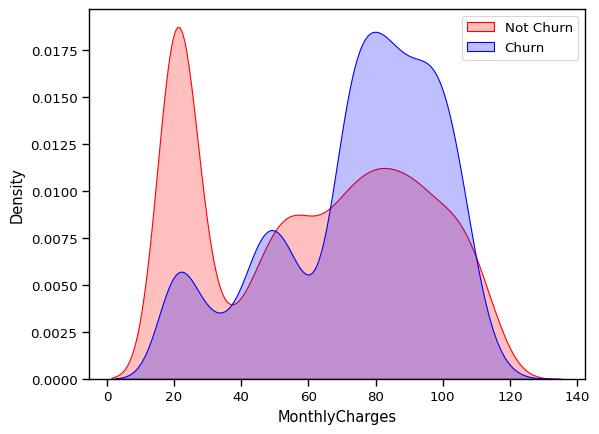

In [628]:
sns.set_context("paper", font_scale=1.1)
ax = sns.kdeplot(df.MonthlyCharges[(df['Churn']== "No")],
            color  = "Red", shade= True)
ax = sns.kdeplot(df.MonthlyCharges[(df['Churn']== "Yes")],
            ax =ax, color  = "Blue", shade= True)
ax.legend(["Not Churn", "Churn"], loc='upper right')
ax.set_xlabel = ("Density")
ax.set_ylabel = ("Monthly Charges")
ax.set_title = ("Distribution of Monthly charges by churn")



Customer with high Monthly charges are also more likely to churn

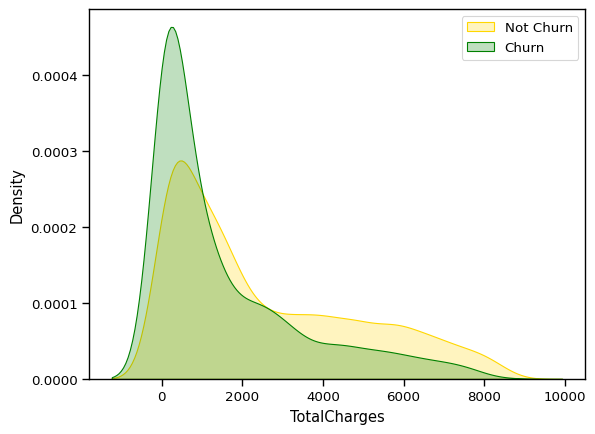

In [629]:
ax = sns.kdeplot(df.TotalCharges[(df['Churn']== "No")],
            color  = "Gold", shade= True)
ax = sns.kdeplot(df.TotalCharges[(df['Churn']== "Yes")],
            ax =ax, color  = "Green", shade= True)
ax.legend(["Not Churn", "Churn"], loc='upper right')
ax.set_xlabel = ("Density")
ax.set_ylabel = ("Total Charges")
ax.set_title = ("Distribution of Monthly charges by churn")


In [630]:
fig = px.box(df, x = 'Churn', y = 'tenure')
# Update Y axes properties 
fig.update_yaxes(title_text = 'Tenure(Months)', row =1 , col=1)

# Update X axes properties 
fig.update_yaxes(title_text = 'Churn', row =1 , col=1)

#Update Size and Title
fig.update_layout(autosize=True, width = 750, height = 600,
     title_font= dict(size =25, family = "courier"),
     title = "<b>Tenure VS Churn</b>"
     )
fig.show()

New Customers are more likely to churn 

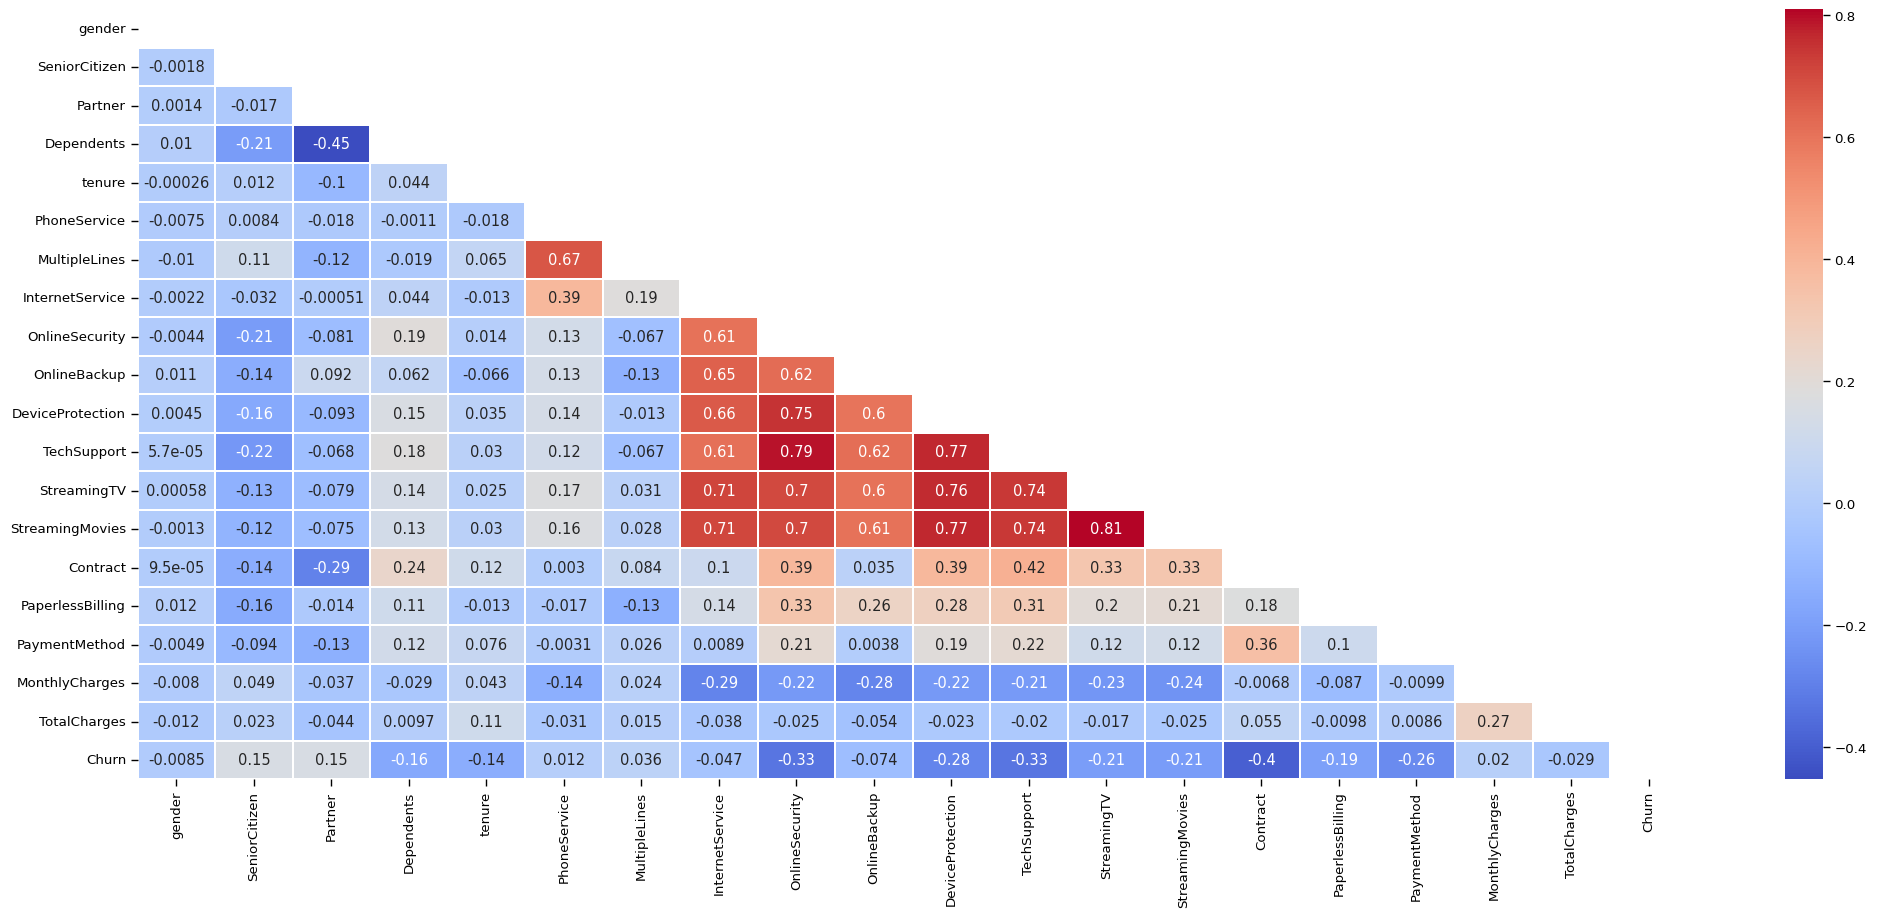

In [631]:
plt.figure(figsize = (25,10))
df_factorized = df.apply(lambda x: pd.factorize(x)[0])
corr = df_factorized.corr()
mask = np.triu(np.ones_like(corr, dtype = bool))
ax = sns.heatmap(corr, mask = mask, xticklabels= corr.columns, yticklabels= corr.columns, annot= True, 
                 linewidths=.2, cmap= 'coolwarm')

## Data Preprocessing

In [632]:
def object_to_int(dataframe_series):
    if dataframe_series.dtype == 'str':
       return LabelEncoder().fit_transform(dataframe_series)
    return dataframe_series

In [633]:
df= df.apply(lambda x: object_to_int(x))


In [634]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [635]:
df.corr()['Churn'].sort_values(ascending = False)


Churn               1.000000
MonthlyCharges      0.192858
PaperlessBilling    0.191454
SeniorCitizen       0.150541
PaymentMethod       0.107852
MultipleLines       0.038043
PhoneService        0.011691
gender             -0.008545
StreamingTV        -0.036303
StreamingMovies    -0.038802
InternetService    -0.047097
Partner            -0.149982
Dependents         -0.163128
DeviceProtection   -0.177883
OnlineBackup       -0.195290
TotalCharges       -0.199484
TechSupport        -0.282232
OnlineSecurity     -0.289050
tenure             -0.354049
Contract           -0.396150
Name: Churn, dtype: float64

In [636]:
X = df.drop(columns = ['Churn'])
y = df['Churn'].values

In [637]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=40, stratify=y)

In [638]:
def distplot(feature, frame, color= 'r'):
    plt.figure(figsize=(8, 3))
    plt.title("Distribution for {}".format(feature))
    ax = sns.distplot(frame[feature], color = color)

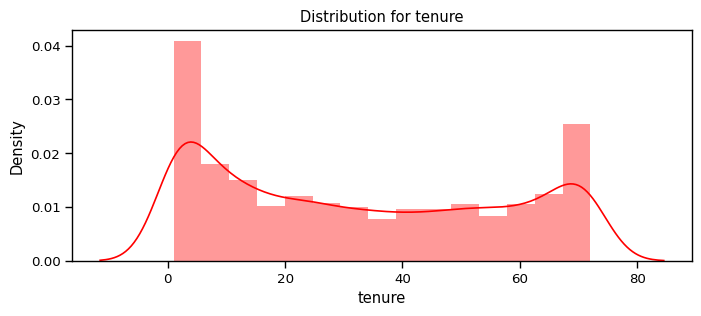

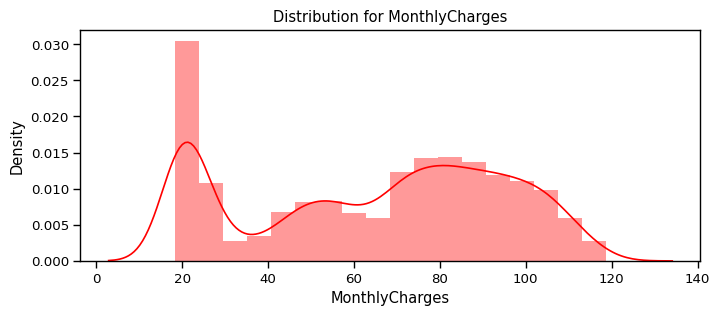

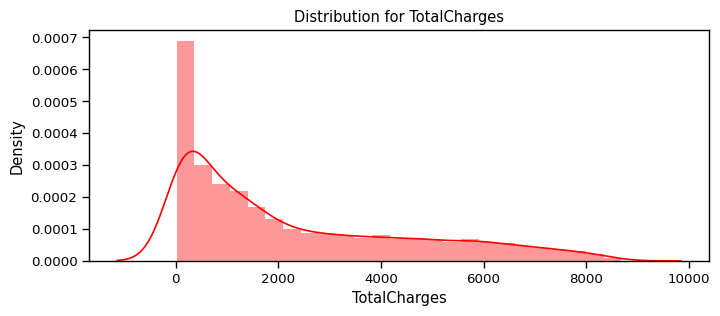

In [639]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
for feat in num_cols: distplot(feat, df)

Since numerical feature are distributed over the different value range, i will use standard scaler to scale them down to the same range 

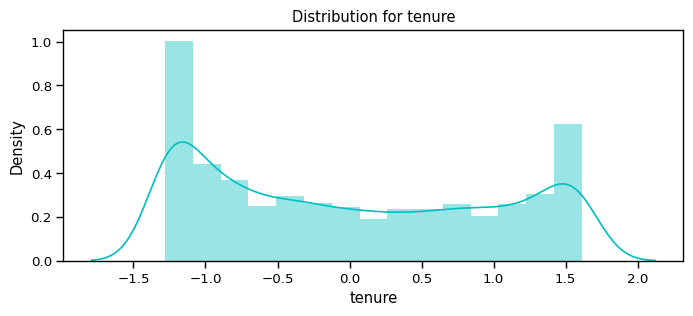

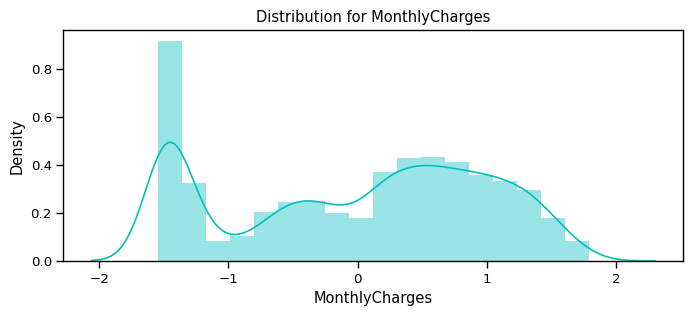

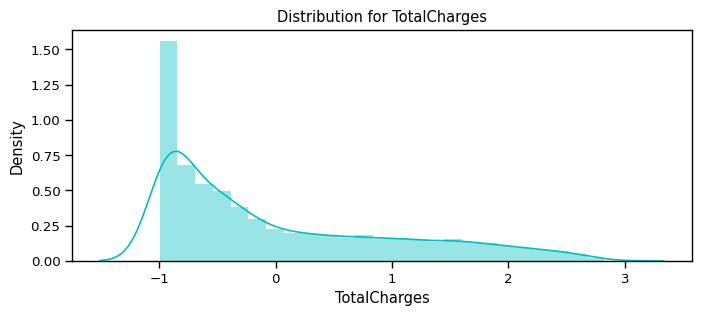

In [640]:
df_std= pd.DataFrame(StandardScaler().fit_transform(df[num_cols].astype('float64')), columns= num_cols)
for feat in numerical_cols:distplot(feat, df_std, color = 'c')
        

In [641]:
#Divide the column into 3 categories, one for standarization, one for label encoding and one for hot encoding
cats_col_ohe = ['PaymentMethod', 'Contract', 'InternetService'] # those that need one hot encoding 
cats_col_le = list(set(X_train.columns)- set(num_cols)- set(cats_col_ohe)) # those that need label encoding

In [642]:
scaler = StandardScaler()

X_train[num_cols]= scaler.fit_transform(X_train[num_cols])
X_test[num_cols]= scaler.transform(X_test[num_cols])

## Machine Learning Model Evaluations and Preditctions


### KNN

In [643]:
knn_model = KNeighborsClassifier(n_neighbors=11)
knn_model.fit(X_train, y_train)
predicted_y = knn_model.predict(X_test)
accuracy_knn = knn_model.score(X_test, y_test)
print("KNN Accuracy:", accuracy_knn)
print(classification_report(y_test, predicted_y))


KNN Accuracy: 0.7758293838862559
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1549
           1       0.59      0.52      0.55       561

    accuracy                           0.78      2110
   macro avg       0.71      0.69      0.70      2110
weighted avg       0.77      0.78      0.77      2110



### SVC

In [644]:
svc_model = SVC(random_state=1)
svc_model.fit(X_train, y_train)
predicted_y = svc_model.predict(X_test)
accuracy_svc = svc_model.score(X_test, y_test)
print("SVC Accuracy:", accuracy_svc)
print(classification_report(y_test, predicted_y))

SVC Accuracy: 0.8075829383886256
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1549
           1       0.69      0.50      0.58       561

    accuracy                           0.81      2110
   macro avg       0.76      0.71      0.73      2110
weighted avg       0.80      0.81      0.80      2110



### Random Forest

In [645]:
rf_model = RandomForestClassifier(n_estimators=500, oob_score=True, n_jobs=-1,
                                  random_state=50, max_depth=None, max_leaf_nodes=30)
rf_model.fit(X_train, y_train)
predicted_test = rf_model.predict(X_test)
print(metrics.accuracy_score(y_test, predicted_test))
print(classification_report(y_test, predicted_test))

0.8137440758293839
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1549
           1       0.71      0.51      0.59       561

    accuracy                           0.81      2110
   macro avg       0.77      0.72      0.74      2110
weighted avg       0.80      0.81      0.80      2110



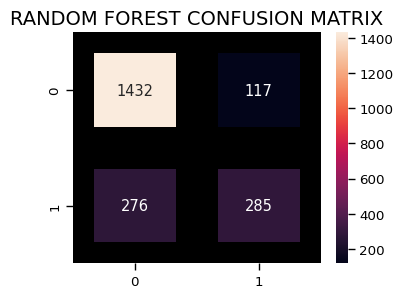

In [646]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, predicted_test),
            annot = True, fmt = "d", linecolor="k", linewidths=30)
plt.title("RANDOM FOREST CONFUSION MATRIX",  fontsize = 14)
plt.show()

### Logistic Regression

In [647]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
accuracy_lr = lr_model.score(X_test, y_test)
print("Logistic Regression Accuracy:", accuracy_lr)
predicted_lr = lr_model.predict(X_test)
print(classification_report(y_test, predicted_lr))


Logistic Regression Accuracy: 0.8090047393364929
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1549
           1       0.66      0.58      0.62       561

    accuracy                           0.81      2110
   macro avg       0.76      0.74      0.75      2110
weighted avg       0.80      0.81      0.80      2110



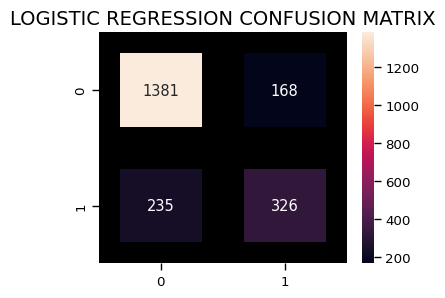

In [648]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, predicted_lr),
            annot = True, fmt = "d", linecolor="k", linewidths=30)
plt.title("LOGISTIC REGRESSION CONFUSION MATRIX",  fontsize = 14)
plt.show()

### Decision Tree Classifier

In [649]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
predicted_y = dt_model.predict(X_test)
accuracy_dt = dt_model.score(X_test, y_test)
print("Decision Tree Classifier Accuracy:", accuracy_dt)
print(classification_report(y_test, predicted_y))

Decision Tree Classifier Accuracy: 0.728909952606635
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1549
           1       0.49      0.53      0.51       561

    accuracy                           0.73      2110
   macro avg       0.66      0.66      0.66      2110
weighted avg       0.74      0.73      0.73      2110



### AdaBoost Classifier 

In [650]:
ad_model = AdaBoostClassifier()
ad_model.fit(X_train, y_train)
predicted_ad = ad_model.predict(X_test)
accuracy_ad = metrics.accuracy_score(y_test, predicted_ad )
print("AdaBoost Classifier Accuracy:", accuracy_ad)
print(classification_report(y_test, predicted_ad))

AdaBoost Classifier Accuracy: 0.8127962085308057
              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1549
           1       0.68      0.56      0.62       561

    accuracy                           0.81      2110
   macro avg       0.76      0.73      0.75      2110
weighted avg       0.81      0.81      0.81      2110



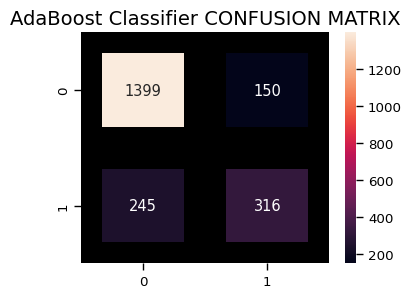

In [651]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, predicted_ad),
            annot = True, fmt = "d", linecolor="k", linewidths=30)
plt.title("AdaBoost Classifier CONFUSION MATRIX",  fontsize = 14)
plt.show()

### Gradient Boosting Classifier

In [652]:
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)
predicted_gb = gb_model.predict(X_test)
accuracy_gb = accuracy_score(y_test, predicted_gb )
print("Gradient Boosting Classifier Accuracy:", accuracy_gb)
print(classification_report(y_test, predicted_gb))

Gradient Boosting Classifier Accuracy: 0.8075829383886256
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1549
           1       0.67      0.55      0.60       561

    accuracy                           0.81      2110
   macro avg       0.76      0.73      0.74      2110
weighted avg       0.80      0.81      0.80      2110



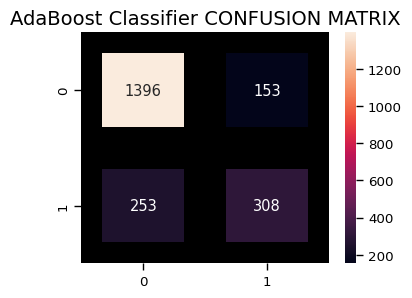

In [653]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, predicted_gb),
            annot = True, fmt = "d", linecolor="k", linewidths=30)
plt.title("AdaBoost Classifier CONFUSION MATRIX",  fontsize = 14)
plt.show()

### Voting Classifier
Let's now predict the final model based on the highest majority of voting and check its score

In [654]:
from sklearn.ensemble import VotingClassifier
clf1 = GradientBoostingClassifier()
clf2 = LogisticRegression()
clf3 = AdaBoostClassifier()
eclf1 = VotingClassifier(estimators=[('gbc', clf1),('lg', clf2), ('abc', clf3)], voting= 'soft')
eclf1.fit(X_train, y_train)
predictions = eclf1.predict(X_test)
accuracy = accuracy_score(y_test, predictions )
print("Final Accuracy Score:", accuracy)
print(classification_report(y_test, predictions))

Final Accuracy Score: 0.8161137440758294
              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1549
           1       0.68      0.57      0.62       561

    accuracy                           0.82      2110
   macro avg       0.77      0.74      0.75      2110
weighted avg       0.81      0.82      0.81      2110



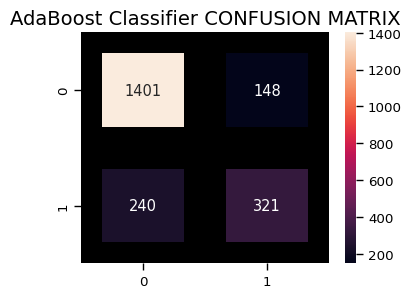

In [655]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, predictions),
            annot = True, fmt = "d", linecolor="k", linewidths=30)
plt.title("AdaBoost Classifier CONFUSION MATRIX",  fontsize = 14)
plt.show()

From the confusion matrix we can see that there are total actually 1549 non churn values and and the alogorithm predict 1400 as non churn while 149 as churn, while there are actual 561 churn values and the algorithm predicts 237 of them as non churn and 324 of them as churn values.